# XGBoost — Strategy A: SMOTE Oversampling

XGBoost is trained using SMOTE oversampling to address the imbalance between diabetes and non-diabetes cases. SMOTE is included in the training pipeline so that synthetic minority samples are generated only within the training folds during cross-validation. Hyperparameter tuning is applied to optimize model complexity, learning rate, tree depth, and sampling parameters.

In [1]:
import pandas as pd
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score, roc_auc_score, classification_report, precision_score, recall_score, f1_score

In [2]:
X_train_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_train_final.parquet")
X_test_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_test_final.parquet")

y_train = pd.read_parquet("../DATASETS/PREPROCESSED/y_train.parquet")["diabetes"]
y_test = pd.read_parquet("../DATASETS/PREPROCESSED/y_test.parquet")["diabetes"]

In [3]:
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.3, 0.5]
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_final, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV ROC AUC:", random_search.best_score_)

Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best parameters: {'model__subsample': 0.8, 'model__n_estimators': 500, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__gamma': 0.1, 'model__colsample_bytree': 1.0}
Best CV ROC AUC: 0.823022837852051


## Final Test Set Evaluation

After hyperparameter tuning, the best model is evaluated on the held-out test set. The test set is not resampled and therefore preserves the original class distribution. Performance is assessed using accuracy, precision, recall, F1-score, ROC AUC, and the confusion matrix.

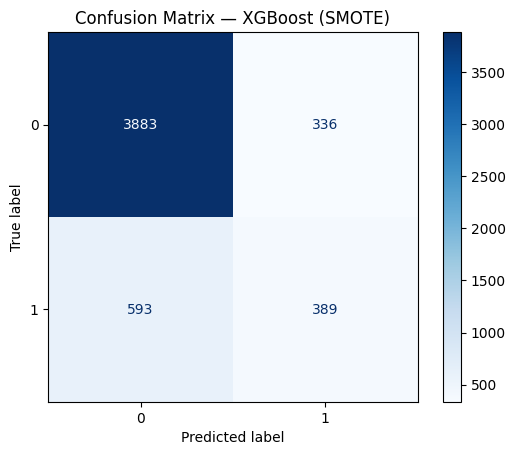

Confusion Matrix:
[[3883  336]
 [ 593  389]]
Accuracy: 0.8214
ROC AUC: 0.8197

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.92      0.89      4219
         1.0       0.54      0.40      0.46       982

    accuracy                           0.82      5201
   macro avg       0.70      0.66      0.67      5201
weighted avg       0.81      0.82      0.81      5201



In [4]:
best_model = random_search.best_estimator_

predictions = best_model.predict(X_test_final)
pred_probabilities = best_model.predict_proba(X_test_final)[:, 1]

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — XGBoost (SMOTE)")
plt.show()

print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y_test, predictions)
roc_auc = roc_auc_score(y_test, pred_probabilities)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))




## Exporting Model Results

The final evaluation metrics are exported to a CSV file so they can be combined later in a separate model comparison notebook. This avoids retraining models when creating summary tables and visualizations.

In [5]:
metrics = {

    "Strategy": "SMOTE",

    "Model": "XGBoost",

    "Accuracy": accuracy_score(y_test, predictions),

    "Precision": precision_score(y_test, predictions),

    "Recall": recall_score(y_test, predictions),

    "F1-score": f1_score(y_test, predictions),

    "ROC AUC": roc_auc_score(y_test, pred_probabilities)

}

metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv("../RESULTS/PERFORMANCE/xgboost_oversampling_metrics.csv", index=False)

## Explainability with SHAP


In [6]:
import shap

/opt/anaconda3/envs/xgb/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|===================| 5180/5201 [00:45<00:00]        /opt/anaconda3/envs/xgb/lib/python3.12/site-packages/shap/plots/_violin.py:322: UserWarning: Not enough data in bin #11 for feature average_alcoholic_drinks_per_day, so it'll be ignored. Try increasing the number of records to plot.
  warnings.warn(
/opt/anaconda3/envs/xgb/lib/python3.12/site-packages/shap/plots/_violin.py:322: UserWarning: Not enough data in bin #13 for feature average_alcoholic_drinks_per_day, so it'll be ignored. Try increasing the number of records to plot.
  warnings.warn(
/opt/anaconda3/envs/xgb/lib/python3.12/site-packages/shap/plots/_violin.py:322: UserWarning: Not enough data in bin #14 for feature average_alcoholic_drinks_per_day, so it'll be ignored. Try increasing the number of records to plot.
  warnings.warn(
/opt/anaconda3/envs/xgb/lib/python3.12/site-packages/shap/plots/_violin.py:322: UserWarning: Not enough data in bin #16 for feature average_alcoholic_drinks_per_day, so it'll be ignored. Try in

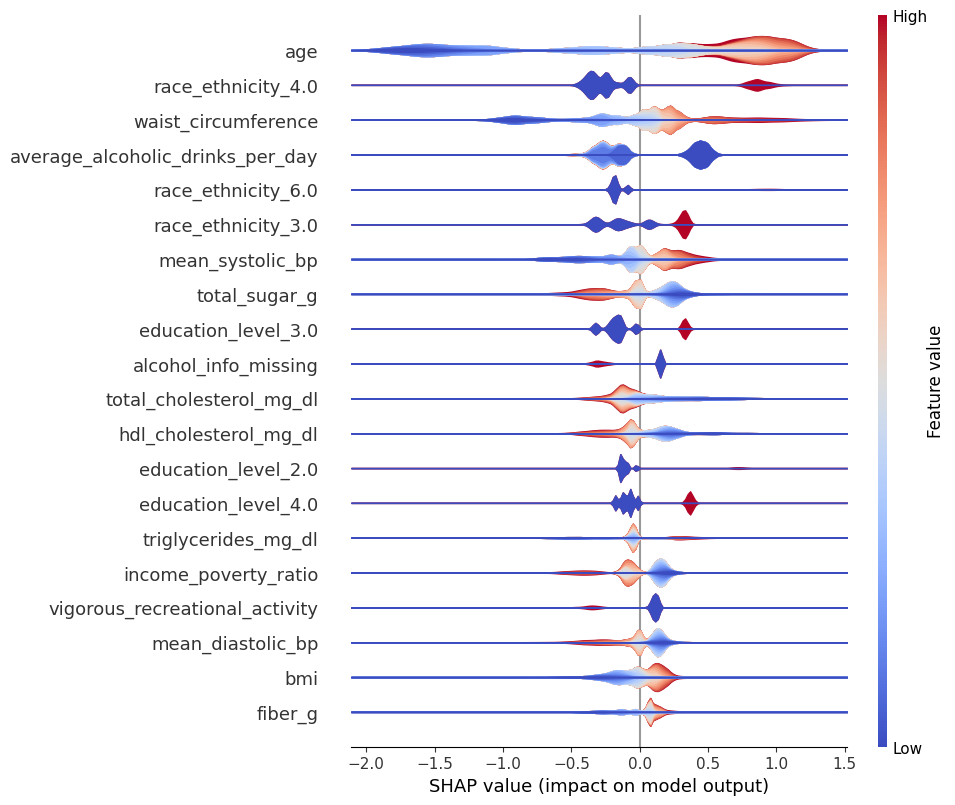

In [ ]:
import numpy as np

est = best_model.named_steps["model"] 

X_train_shap = X_train_final.astype(np.float64)
X_test_shap = X_test_final.astype(np.float64)

background = X_train_shap.sample(n=min(100, len(X_train_shap)), random_state=0)

explainer = shap.TreeExplainer(est, data=background)
sv = explainer.shap_values(X_test_shap)

if isinstance(sv, list):
    sv = sv[1]

shap.plots.violin(
    sv,
    features=X_test_shap,
    feature_names=list(X_test_shap.columns),
    plot_type="layered_violin"
)

## Explainability with Permutation


In [52]:
from sklearn.inspection import permutation_importance

In [53]:
perm_importance = permutation_importance(
    est,
    X_test_final,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="accuracy"
)

,Feature,Importance Mean,Importance Std
29,race_ethnicity_4.0,0.040290,0.002565
28,race_ethnicity_3.0,0.032744,0.002257
0,age,0.019737,0.002084
25,alcohol_info_missing,0.017872,0.002600
30,race_ethnicity_6.0,0.016026,0.001981
34,education_level_4.0,0.013536,0.002012
7,average_alcoholic_drinks_per_day,0.013401,0.001654
33,education_level_3.0,0.012873,0.002162
32,education_level_2.0,0.012594,0.001966
27,race_ethnicity_2.0,0.010027,0.002093


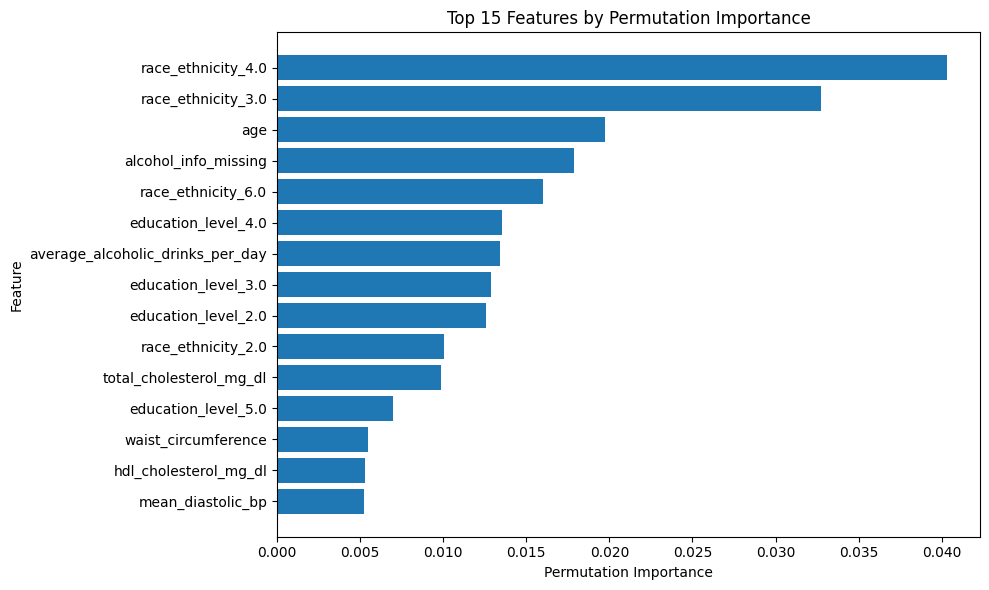

In [51]:
importance_df = pd.DataFrame({
    "Feature": X_test_final.columns,
    "Importance Mean": perm_importance.importances_mean,
    "Importance Std": perm_importance.importances_std
})

importance_df = importance_df.sort_values(
    by="Importance Mean",
    ascending=False
)

importance_df = importance_df.sort_values(
    by="Importance Mean",
    ascending=False
)

display(importance_df)

# Plot Top 15 Features
top_n = 15

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["Feature"][:top_n][::-1],
    importance_df["Importance Mean"][:top_n][::-1]
)
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features by Permutation Importance")
plt.tight_layout()
plt.show()


## Explainability with built-in XGBoost feature importance

In [56]:
import pandas as pd
import matplotlib.pyplot as plt


In [57]:
model = best_model.named_steps["model"]

booster = model.get_booster()
importance = booster.get_score(importance_type="gain")

importance_df = pd.DataFrame(
    importance.items(),
    columns=["Feature", "Gain"]
).sort_values("Gain", ascending=False)

display(importance_df)

,Feature,Gain
11,vigorous_recreational_activity,155.241974
12,moderate_recreational_activity,144.498581
0,age,142.795837
10,walk_or_bicycle_transport,141.223160
6,ever_smoked_100_cigarettes,120.932251
9,moderate_work_activity,113.155113
25,alcohol_info_missing,60.600731
8,vigorous_work_activity,59.571190
3,waist_circumference,58.486828
7,average_alcoholic_drinks_per_day,33.291695


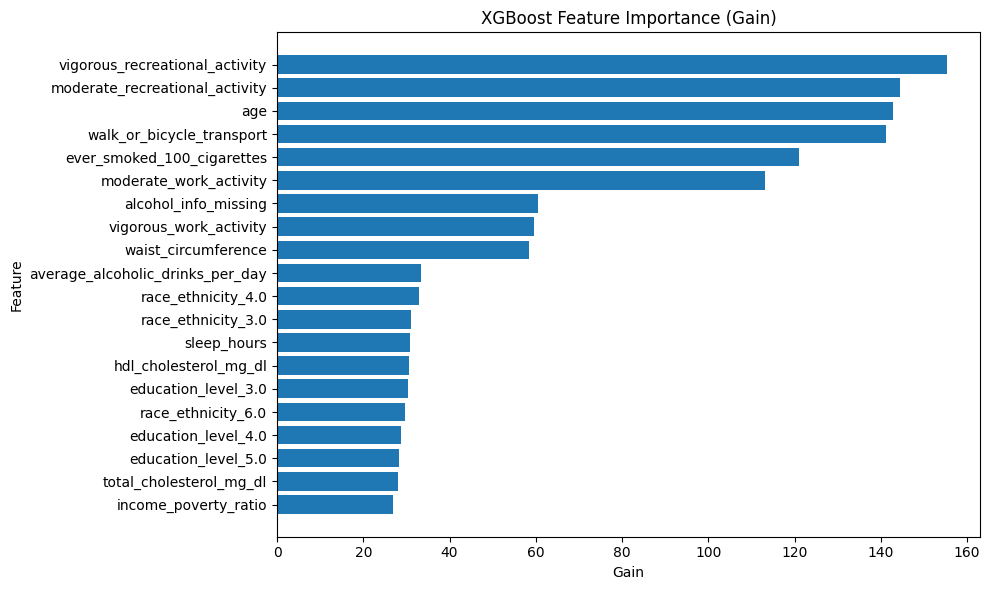

In [58]:
top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_df["Feature"][::-1],
    plot_df["Gain"][::-1]
)

plt.xlabel("Gain")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.show()